C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14044\1627129198.py:91: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')
C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598
Class weight: {0: 0.5337894209911563, 1: 7.898765432098766}
Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7155 - loss: 0.4585 - val_accuracy: 0.5622 - val_loss: 0.7170 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7626 - loss: 0.4159 - val_accuracy: 0.5745 - val_loss: 0.6910 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7711 - loss: 0.4116 - val_accuracy: 0.5832 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7650 - loss: 0.4066 - val_accuracy: 0.6019 - val_loss: 0.6777 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7725 - loss: 0.4032 - val_accuracy: 0.5792 - val_loss: 0.6779 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step 

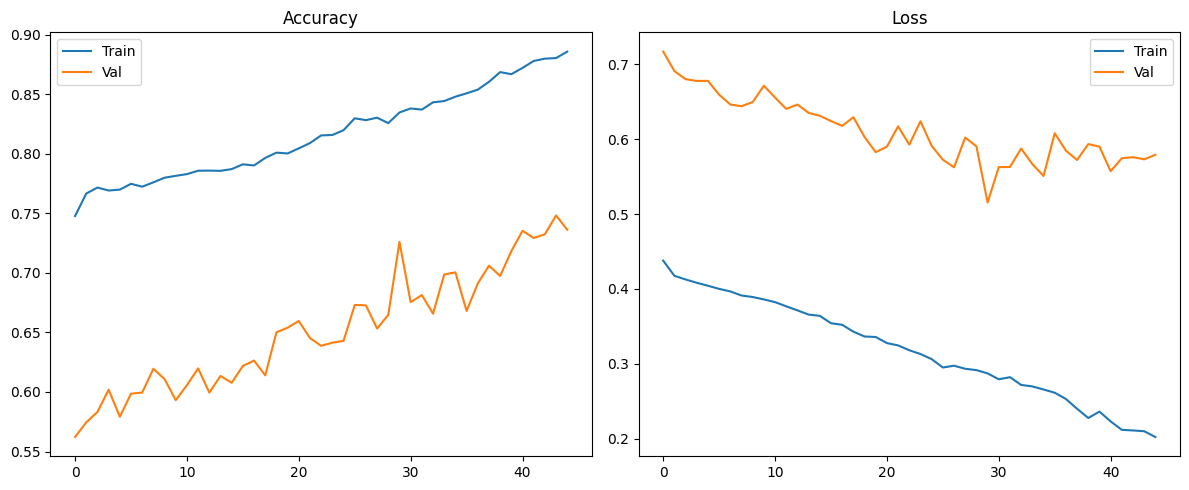


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_pembanding_GRU_1jam\best_model.keras
Scaler : ./model_pembanding_GRU_1jam\scaler_X.joblib


In [2]:
# ============================
# MOdel Pembanding GRU
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_pembanding_GRU_1jam'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build GRU Model (Model Pembanding)
# ===============================
from keras.layers import GRU

# Ganti 'model_gru' menjadi 'model'
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.3),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GRU(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14044\1593174280.py:90: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')
C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598
Class weight: {0: 0.5337894209911563, 1: 7.898765432098766}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 10, 64)              │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 3, 32)               │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,289 (32.38 KB)

 Trainable params: 8,289 (32.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6926 - loss: 0.5009 - val_accuracy: 0.5855 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7492 - loss: 0.4373 - val_accuracy: 0.5780 - val_loss: 0.7059 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7522 - loss: 0.4275 - val_accuracy: 0.5590 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7477 - loss: 0.4276 - val_accuracy: 0.5625 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7533 - loss: 0.4195 - val_accuracy: 0.5701 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7573 - loss: 0.4184 - val_accuracy: 0.5610 - val_loss: 0.7168 - learning_rate: 0.0010
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7557 - loss: 0.

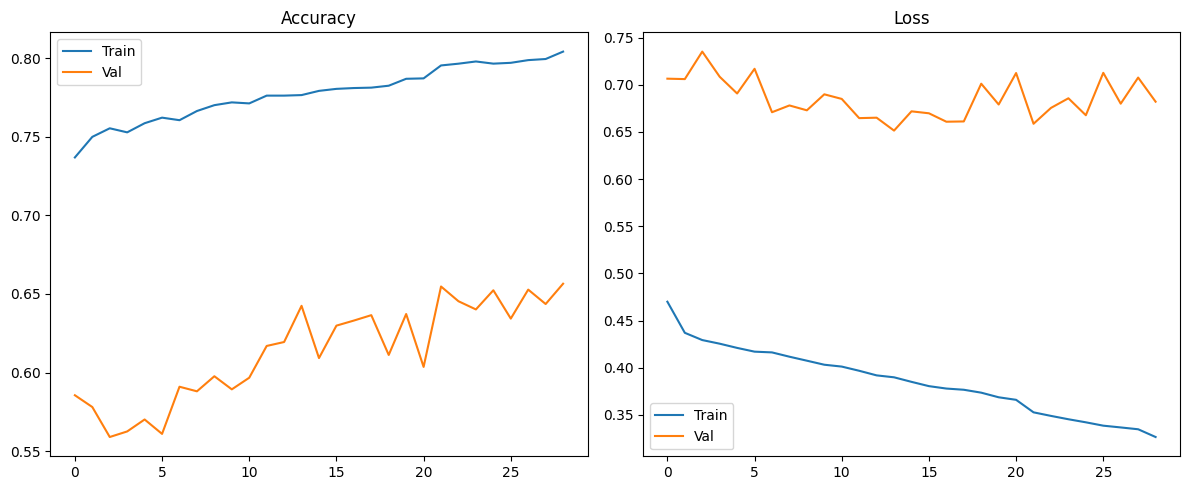


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_pembanding_1D-CNN_1jam\best_model.keras
Scaler : ./model_pembanding_1D-CNN_1jam\scaler_X.joblib


In [3]:
# ============================
# MOdel Pembanding 1D-CNN
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_pembanding_1D-CNN_1jam'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build 1D-CNN Model
# ===============================
from keras.layers import Conv1D, MaxPooling1D, Flatten

model = Sequential([
    # Layer pertama: Mencari pola lokal dengan 64 filter
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(time_steps, X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    
    # Layer kedua: Mencari pola yang lebih kompleks
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14044\1874424724.py:90: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598
Class weight: {0: 0.5337894209911563, 1: 7.898765432098766}


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 10, 64)              │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 8, 32)               │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 8, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,993 (175.75 KB)

 Trainable params: 44,993 (175.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7579 - loss: 0.4973 - val_accuracy: 0.6103 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7741 - loss: 0.4249 - val_accuracy: 0.6397 - val_loss: 0.6444 - learning_rate: 0.0010
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7839 - loss: 0.4196 - val_accuracy: 0.6017 - val_loss: 0.6989 - learning_rate: 0.0010
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7804 - loss: 0.4107 - val_accuracy: 0.5937 - val_loss: 0.6604 - learning_rate: 0.0010
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7747 - loss: 0.4090 - val_accuracy: 0.6204 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7823 - loss: 0.4029 - val_accuracy: 0.6174 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7822 - loss: 0.

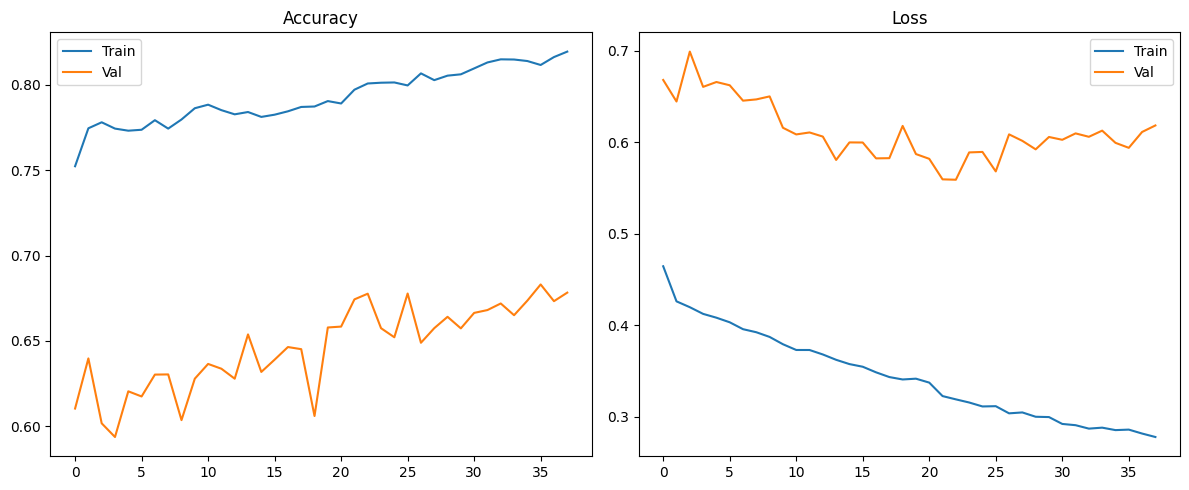


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_pembanding_CNN-LSTM_1jam\best_model.keras
Scaler : ./model_pembanding_CNN-LSTM_1jam\scaler_X.joblib


In [4]:
# ============================
# MOdel Pembanding CNN-LSTM
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_pembanding_CNN-LSTM_1jam'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build CNN-LSTM Hybrid Model
# ===============================
from keras.layers import Conv1D, MaxPooling1D, LSTM, TimeDistributed

model = Sequential([
    # Tahap 1: Feature Extraction menggunakan CNN
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(time_steps, X_train.shape[2])),
    # Kita tidak menggunakan MaxPooling yang terlalu besar agar dimensi waktu tidak habis sebelum masuk ke LSTM
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    
    # Tahap 2: Sequence Learning menggunakan LSTM
    # Kita tambahkan layer LSTM untuk belajar dari fitur yang sudah diekstrak CNN
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    
    # Tahap 3: Classification
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14044\1640512751.py:90: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='linear', inplace=True, limit_direction='both')


Distribusi kelas: {0: 44792, 1: 3217}
Sequence shape: (47986, 12, 5)
Train samples: 38388
Test samples : 9598
Class weight: {0: 0.5337894209911563, 1: 7.898765432098766}


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8077 - loss: 0.3161 - val_accuracy: 0.6756 - val_loss: 0.5769 - learning_rate: 6.2500e-05
Epoch 2/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8077 - loss: 0.3116 - val_accuracy: 0.6762 - val_loss: 0.5766 - learning_rate: 6.2500e-05
Epoch 3/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8089 - loss: 0.3079 - val_accuracy: 0.6808 - val_loss: 0.5735 - learning_rate: 6.2500e-05
Epoch 4/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8114 - loss: 0.3080 - val_accuracy: 0.6786 - val_loss: 0.5728 - learning_rate: 6.2500e-05
Epoch 5/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8113 - loss: 0.3052 - val_accuracy: 0.6768 - val_loss: 0.5794 - learning_rate: 6.2500e-05
Epoch 6/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8120 - loss: 0.3033 - val_accuracy: 0.6822 - val_loss: 0.5786 - learning_rate: 6.2500e-05
Epoch 7/500
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc

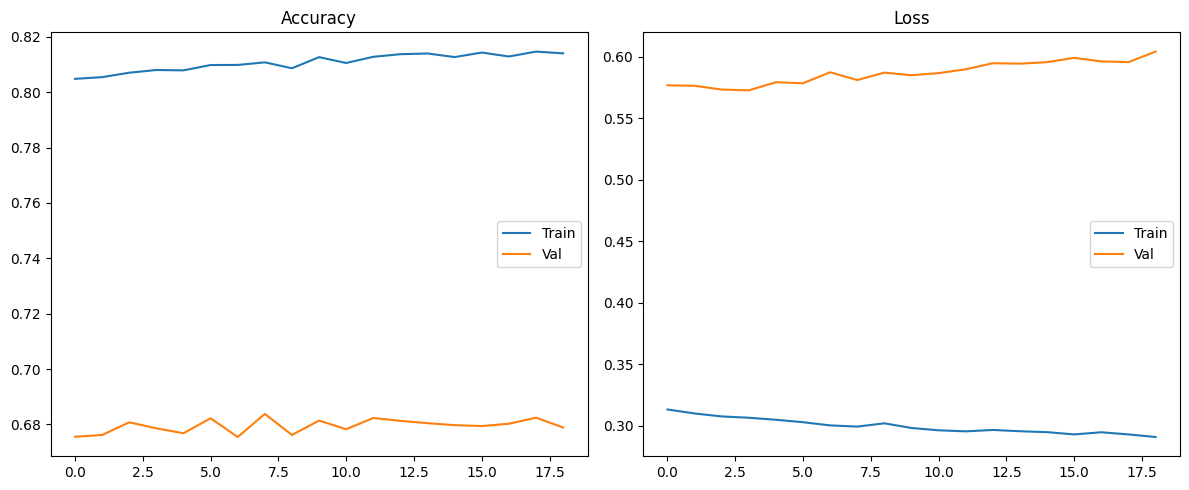


TRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN
Model  : ./model_pembanding_BI-LSTM_1jam\best_model.keras
Scaler : ./model_pembanding_BI-LSTM_1jam\scaler_X.joblib


In [5]:
# ============================
# MOdel Pembanding BI-LSTM
# ============================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===============================
# 0. Reproducibility
# ===============================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===============================
# 1. Paths & Config
# ===============================
DATA_PATH = r'./sensor_curah_corrected_finalV2.csv'
OUT_DIR = r'./model_pembanding_BI-LSTM_1jam'
os.makedirs(OUT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.keras')
SCALER_PATH = os.path.join(OUT_DIR, 'scaler_X.joblib')
HISTORY_CSV = os.path.join(OUT_DIR, 'training_history.csv')
TEST_PRED_CSV = os.path.join(OUT_DIR, 'test_predictions.csv')
BEST_THR_TXT = os.path.join(OUT_DIR, 'best_threshold.txt')

# ===============================
# 2. Parameters
# ===============================
time_steps = 12        # 1 jam history (12 x 5 menit)
horizon_steps = 12     # 1 jam ke depan
test_ratio = 0.2
batch_size = 64
epochs = 500

# ===============================
# 3. Load & Prepare Data
# ===============================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

# Build Datetime
if 'Datetime' not in df.columns:
    df['Datetime'] = pd.to_datetime(
        df['Tanggal'].astype(str) + ' ' + df['Jam'].astype(str),
        dayfirst=True,
        errors='coerce'
    )

df = df.sort_values('Datetime').reset_index(drop=True)

# ===============================
# 4. Target & Features (FOCUS)
# ===============================
TARGET_COL = 'Curah_Hujan_corrected'

FEATURES = [
    'Curah_Hujan_corrected',
    'Curah_Hujan_original',
    'Suhu',
    'Kelembaban',
    'Kecepatan_Angin'
]

# Validasi kolom
missing = [c for c in FEATURES + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Kolom tidak ditemukan: {missing}")

# Konversi numeric
for c in FEATURES + [TARGET_COL]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df.interpolate(method='linear', inplace=True, limit_direction='both')
df.dropna(subset=FEATURES + [TARGET_COL], inplace=True)
df.reset_index(drop=True, inplace=True)

# Binary label
df['Hujan'] = (df[TARGET_COL] > 0).astype(int)
print("Distribusi kelas:", df['Hujan'].value_counts().to_dict())

# ===============================
# 5. Raw X & y (BELUM DISCALING)
# ===============================
X_raw = df[FEATURES].values
y_raw = df['Hujan'].values

# ===============================
# 6. Create Sequences
# ===============================
def create_sequences(X, y, time_steps, horizon_steps):
    Xs, ys, idxs = [], [], []
    max_i = len(X) - time_steps - horizon_steps + 1

    for i in range(max_i):
        Xs.append(X[i:i+time_steps])
        label_idx = i + time_steps + horizon_steps - 1
        ys.append(y[label_idx])
        idxs.append(label_idx)

    return np.array(Xs), np.array(ys), np.array(idxs)

X_seq, y_seq, idx_seq = create_sequences(
    X_raw, y_raw,
    time_steps, horizon_steps
)

print("Sequence shape:", X_seq.shape)

# ===============================
# 7. TIME-BASED SPLIT
# ===============================
split_idx = int(len(X_seq) * (1 - test_ratio))

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]

y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

idx_test = idx_seq[split_idx:]

print("Train samples:", len(y_train))
print("Test samples :", len(y_test))

# ===============================
# 8. Scaling (FIT ONLY ON TRAIN)
# ===============================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, SCALER_PATH)

# ===============================
# 9. Class Weights
# ===============================
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

# ===============================
# 10. Build BI-LSTM
# ===============================
from keras.layers import Bidirectional

model_bilstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===============================
# 11. Callbacks
# ===============================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5, min_lr=1e-6),
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True)
]

# ===============================
# 12. Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

pd.DataFrame(history.history).to_csv(HISTORY_CSV, index=False)

# ===============================
# 13. Evaluation + Best Threshold
# ===============================
y_prob = model.predict(X_test).flatten()

thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr, best_f1 = 0.5, -1

for thr in thr_grid:
    y_pred = (y_prob >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

y_best = (y_prob >= best_thr).astype(int)

print("\n=== BEST THRESHOLD (F1) ===")
print("Threshold :", best_thr)
print("Accuracy :", accuracy_score(y_test, y_best))
print("Precision:", precision_score(y_test, y_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_best, zero_division=0))
print("F1-score :", f1_score(y_test, y_best, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))

with open(BEST_THR_TXT, "w") as f:
    f.write(str(best_thr))

# ===============================
# 14. Save Test Predictions
# ===============================
df_out = df.iloc[idx_test].copy().reset_index(drop=True)
df_out['y_true'] = y_test
df_out['pred_prob'] = y_prob
df_out['pred_best'] = y_best

df_out.to_csv(TEST_PRED_CSV, index=False)

# ===============================
# 15. Plot Curves
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nTRAINING SELESAI — MODEL TIME-BASED SIAP DIGUNAKAN")
print("Model  :", BEST_MODEL_PATH)
print("Scaler :", SCALER_PATH)


In [6]:
# ===============================
# PEMBANDING: RANDOM FOREST
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_auc_score
)

print("\n=== MEMULAI TRAINING RANDOM FOREST ===")

# 1. Flatten Data (Ubah dari 3D ke 2D)
# Random Forest tidak menerima input (samples, time_steps, features)
# Kita ubah menjadi (samples, time_steps * features)
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf  = X_test.reshape(X_test.shape[0], -1)

# 2. Inisialisasi Model
# n_estimators: Jumlah pohon (100-200 cukup untuk baseline)
# class_weight='balanced': Sangat penting karena data Anda imbalanced
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,        # Batasi kedalaman agar tidak terlalu overfit
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1            # Menggunakan semua core CPU agar cepat
)

# 3. Training
rf_model.fit(X_train_rf, y_train)

# 4. Prediksi Probabilitas
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# 5. Cari Threshold Terbaik untuk F1-Score
thr_grid = np.arange(0.1, 0.9, 0.01)
best_thr_rf, best_f1_rf = 0.5, -1

for thr in thr_grid:
    y_pred_rf = (y_prob_rf >= thr).astype(int)
    f1 = f1_score(y_test, y_pred_rf, zero_division=0)
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_thr_rf = thr

# 6. Evaluasi Final dengan Best Threshold
y_best_rf = (y_prob_rf >= best_thr_rf).astype(int)

print("\n=== HASIL RANDOM FOREST (BEST F1) ===")
print(f"Best Threshold : {best_thr_rf:.2f}")
print(f"Accuracy       : {accuracy_score(y_test, y_best_rf):.4f}")
print(f"Precision      : {precision_score(y_test, y_best_rf, zero_division=0):.4f}")
print(f"Recall         : {recall_score(y_test, y_best_rf, zero_division=0):.4f}")
print(f"F1-score       : {f1_score(y_test, y_best_rf, zero_division=0):.4f}")
print(f"ROC AUC        : {roc_auc_score(y_test, y_prob_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_best_rf))


=== MEMULAI TRAINING RANDOM FOREST ===

=== HASIL RANDOM FOREST (BEST F1) ===
Best Threshold : 0.74
Accuracy       : 0.8876
Precision      : 0.3333
Recall         : 0.3710
F1-score       : 0.3512
ROC AUC        : 0.7881
Confusion Matrix:
 [[8227  584]
 [ 495  292]]


In [9]:
import pandas as pd

# 1. Inisialisasi list results jika belum ada
results = []

# 2. Fungsi pembantu untuk menghitung metrik (Thresholding Otomatis)
def get_metrics(name, y_true, y_prob_or_pred, is_binary=False):
    if is_binary:
        # Untuk Naive atau Random Forest (jika output sudah class)
        y_best = y_prob_or_pred
        y_prob = y_prob_or_pred
    else:
        # Cari threshold terbaik untuk model Deep Learning
        thr_grid = np.arange(0.1, 0.9, 0.01)
        best_thr, best_f1 = 0.5, -1
        for thr in thr_grid:
            y_p = (y_prob_or_pred >= thr).astype(int)
            f1 = f1_score(y_true, y_p, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = thr
        y_best = (y_prob_or_pred >= best_thr).astype(int)
        y_prob = y_prob_or_pred

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_best),
        'Precision': precision_score(y_true, y_best, zero_division=0),
        'Recall': recall_score(y_true, y_best, zero_division=0),
        'F1-Score': f1_score(y_true, y_best, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_prob)
    }

# 3. Masukkan hasil Naive Predictor yang baru saja Anda hitung
# (Gunakan variabel dari sel Anda sebelumnya)
results.append(get_metrics('Naive Predictor', y_test, y_pred_naive, is_binary=True))

# 4. Ambil otomatis dari model-model Deep Learning yang ada di memori
# Sesuaikan nama variabel model jika berbeda
model_map = {
    'LSTM': 'model', # atau model_lstm
    'GRU': 'model_gru',
    '1D-CNN': 'model_cnn',
    'Bi-LSTM': 'model_bilstm',
    'CNN-LSTM Hybrid': 'model_hybrid'
}

for label, var_name in model_map.items():
    if var_name in globals():
        m = globals()[var_name]
        prob = m.predict(X_test).flatten()
        results.append(get_metrics(label, y_test, prob))

# 5. Ambil hasil Random Forest
if 'rf_model' in globals():
    X_test_rf = X_test.reshape(X_test.shape[0], -1)
    prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]
    results.append(get_metrics('Random Forest', y_test, prob_rf))

# 6. Tampilkan Tabel
df_final = pd.DataFrame(results).drop_duplicates(subset=['Model'])
df_final = df_final.sort_values('F1-Score', ascending=False).reset_index(drop=True)

display(df_final.style.highlight_max(axis=0, color='lightgreen').format(precision=4))

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Naive Predictor,0.8998,0.3856,0.3748,0.3802,0.6607
1,LSTM,0.8921,0.3564,0.3926,0.3736,0.7907
2,Random Forest,0.8876,0.3333,0.3710,0.3512,0.7881
3,GRU,0.7109,0.1437,0.5095,0.2242,0.6818
4,Bi-LSTM,0.3784,0.1048,0.8729,0.1872,0.5624


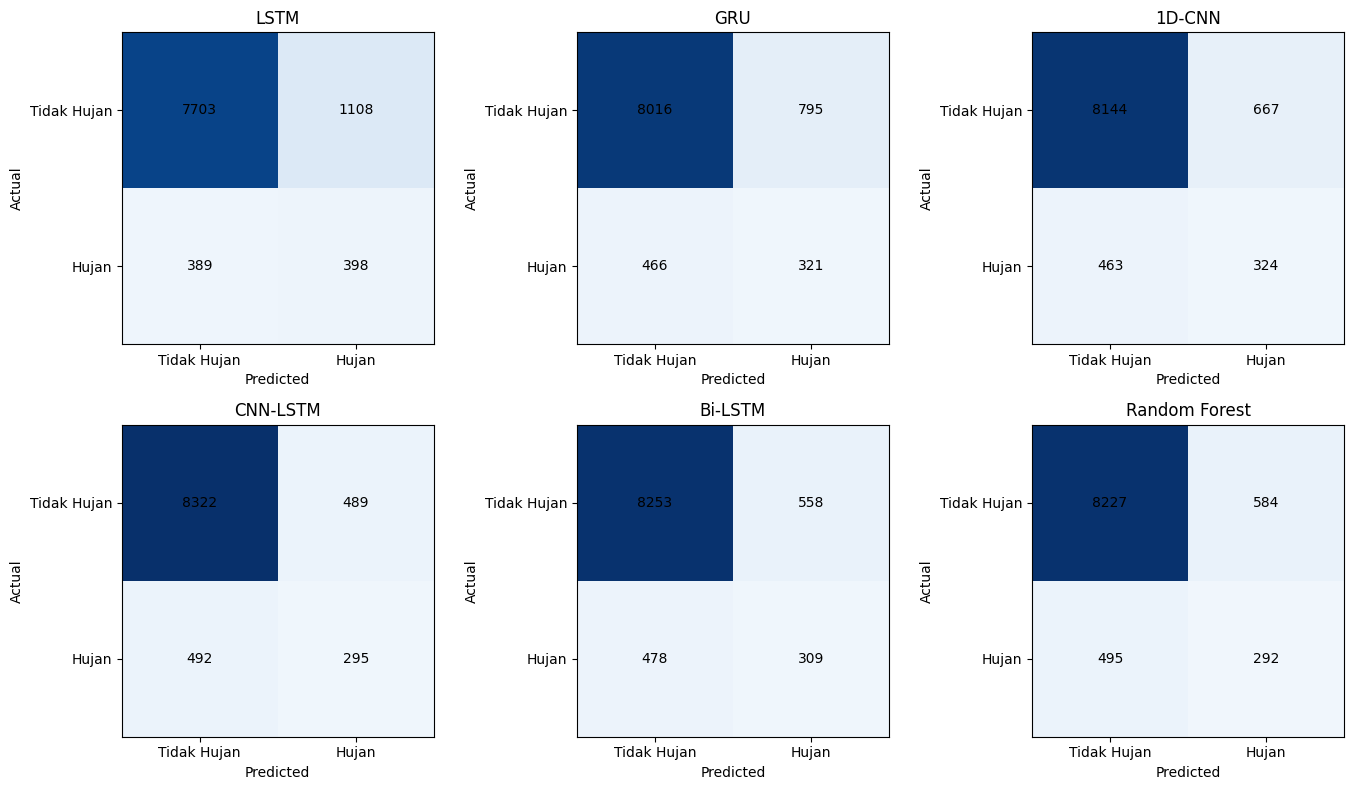

In [8]:
import matplotlib.pyplot as plt
import numpy as np

cm_data = {
    "LSTM": np.array([[7703,1108],[389,398]]),
    "GRU": np.array([[8016,795],[466,321]]),
    "1D-CNN": np.array([[8144,667],[463,324]]),
    "CNN-LSTM": np.array([[8322,489],[492,295]]),
    "Bi-LSTM": np.array([[8253,558],[478,309]]),
    "Random Forest": np.array([[8227,584],[495,292]])
}

# Skala warna sama untuk semua
max_value = max(cm.max() for cm in cm_data.values())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, cm) in zip(axes.flatten(), cm_data.items()):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=max_value)
    ax.set_title(name)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Tidak Hujan", "Hujan"])
    ax.set_yticklabels(["Tidak Hujan", "Hujan"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Tambahkan angka
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center",
                    va="center",
                    color="black")

plt.tight_layout()
plt.savefig("Confusion_Matrix_All_Models_Final_NoColorbar.png", dpi=300)
plt.show()